In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,r2_score

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/BIA - Internship Projects/Datasets/energydata_complete.csv")

# This dataset contains appliance energy consumption along with environmental factors
# such as temperature, humidity, and time-based features.

# EDA and Preprocessing

In [ ]:
# Performing Exploratory Data Analysis (EDA) to understand data distribution,
# identify skewness, outliers, and relationships between variables.

In [ ]:
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,11-01-2016 17:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.60,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,11-01-2016 17:10,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.48,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,11-01-2016 17:20,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.37,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,11-01-2016 17:30,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.25,733.8,92.0,6.000000,51.500000,5.0,45.410390,45.410390
4,11-01-2016 17:40,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.13,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


These are the first 5 rows of our dataset.

In [ ]:
df.tail()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
19730,27-05-2016 17:20,100,0,25.566667,46.560000,25.890000,42.025714,27.200000,41.163333,24.7,...,23.2,46.7900,22.7,755.2,55.666667,3.333333,23.666667,13.3,43.096812,43.096812
19731,27-05-2016 17:30,90,0,25.500000,46.500000,25.754000,42.080000,27.133333,41.223333,24.7,...,23.2,46.7900,22.6,755.2,56.000000,3.500000,24.500000,13.3,49.282940,49.282940
19732,27-05-2016 17:40,270,10,25.500000,46.596667,25.628571,42.768571,27.050000,41.690000,24.7,...,23.2,46.7900,22.5,755.2,56.333333,3.666667,25.333333,13.3,29.199117,29.199117
19733,27-05-2016 17:50,420,10,25.500000,46.990000,25.414000,43.036000,26.890000,41.290000,24.7,...,23.2,46.8175,22.3,755.2,56.666667,3.833333,26.166667,13.2,6.322784,6.322784
19734,27-05-2016 18:00,430,10,25.500000,46.600000,25.264286,42.971429,26.823333,41.156667,24.7,...,23.2,46.8450,22.2,755.2,57.000000,4.000000,27.000000,13.2,34.118851,34.118851


These are the last 5 rows of our dataset.

In [ ]:
df.describe()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.412580,755.522602,79.750418,4.039752,38.330834,3.760995,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.318464,7.399441,14.901088,2.451221,11.794719,4.195248,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.670000,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.920000,756.100000,83.666667,3.666667,40.000000,3.430000,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.400000,760.933333,91.666667,5.500000,40.000000,6.570000,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


1. Average energy usage of the Appliances is 97.69(Wh).
2. Maximum energy usage of the light fixtures is 70.00(Wh).
3. Minimum temperature outside which was recorded by Chievres Weather Station is -5(in Celcius).

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9  

Our target variable is "**Appliances**".

In [ ]:
df.dtypes

,0
date,object
Appliances,int64
lights,int64
T1,float64
RH_1,float64
T2,float64
RH_2,float64
T3,float64
RH_3,float64
T4,float64


Except Date feature, all other features are numeric.

In [ ]:
df.nunique()

,0
date,19735
Appliances,92
lights,8
T1,722
RH_1,2547
T2,1650
RH_2,3376
T3,1426
RH_3,2618
T4,1390


In [ ]:
df.duplicated().value_counts()

,count
False,19735


There is no duplicate value.

In [ ]:
df.shape

(19735, 29)

This is the intial count of Rows(19735) and Columns(29).

In [ ]:
df.isna().sum()

,0
date,0
Appliances,0
lights,0
T1,0
RH_1,0
T2,0
RH_2,0
T3,0
RH_3,0
T4,0


*   There is Zero NULL value in our data, but that doesn't mean that we will directly use it for modeling.
*   First we will clean the data, observe correlation between the features, split the data into X & Y, then we will go for modeling.

<Axes: >

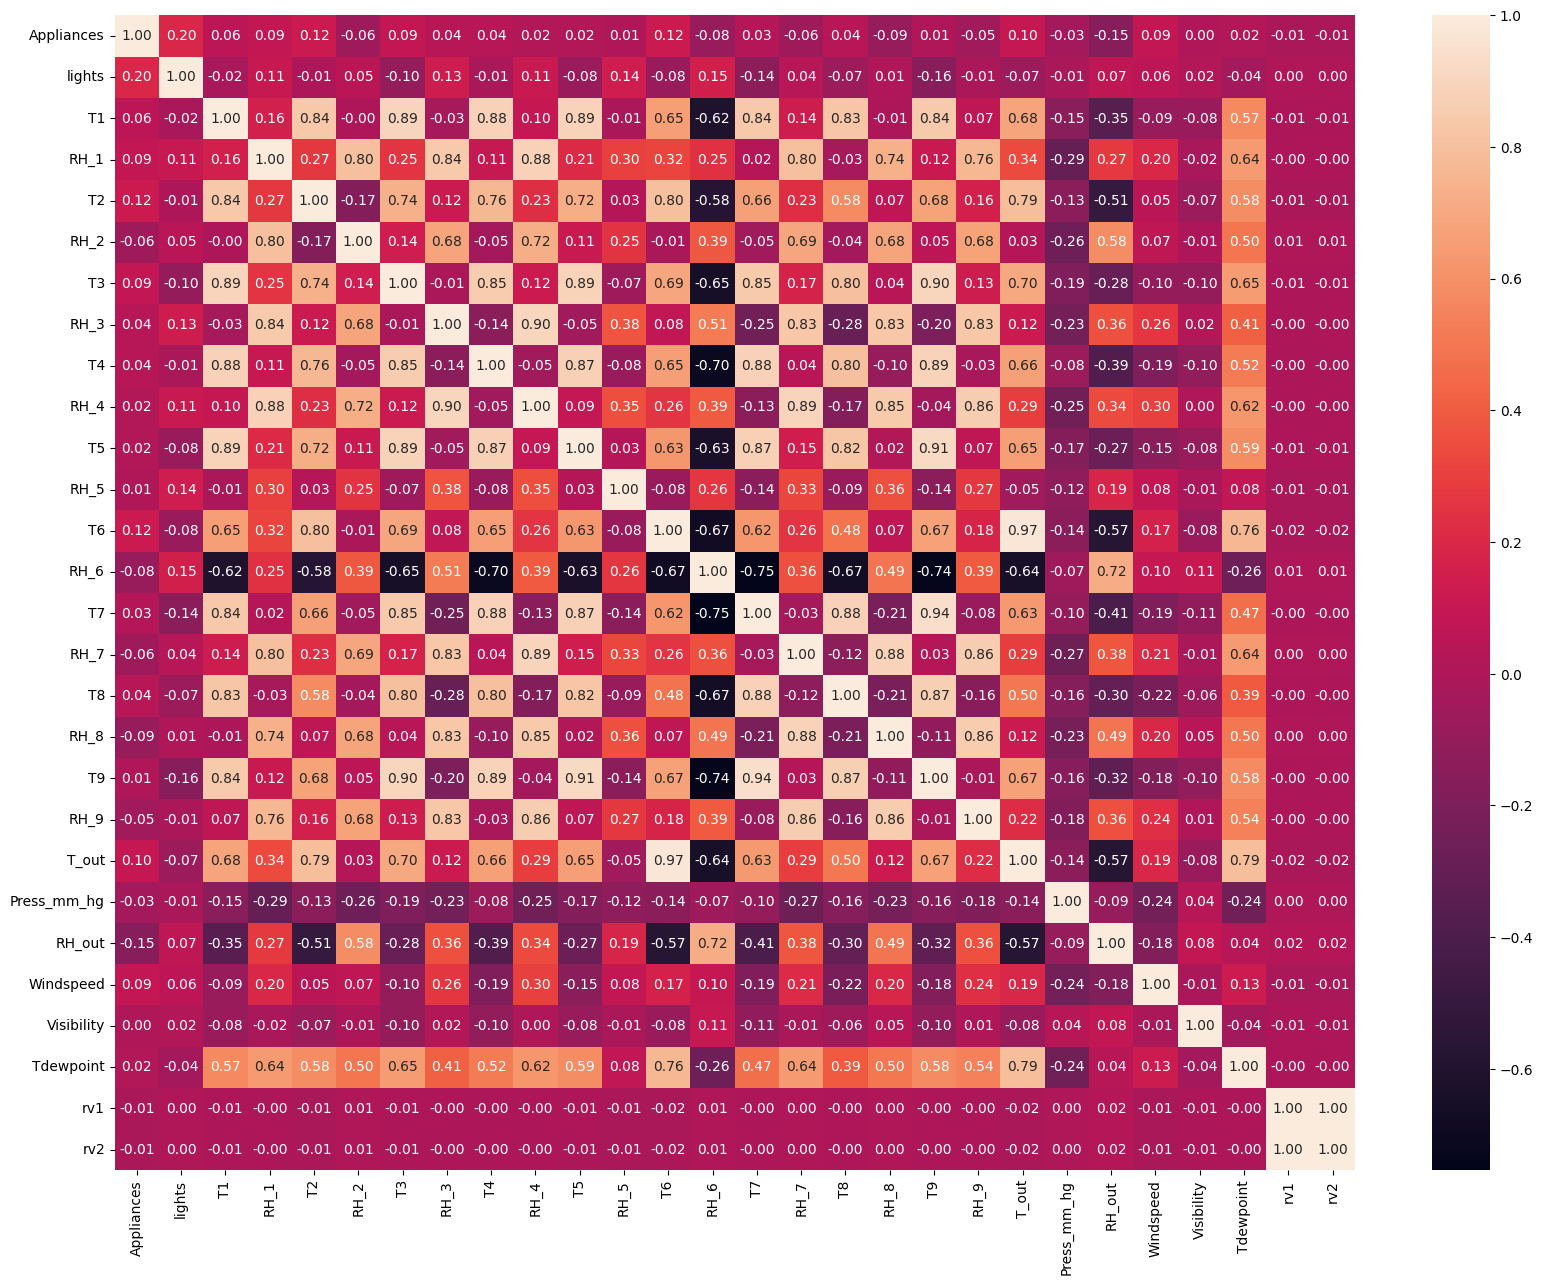

In [ ]:
cor=df.corr(numeric_only=True)
plt.figure(figsize=(20,15))
sns.heatmap(cor,annot=True,fmt=".2f")

*   The heatmap shows that most features have weak correlation with Appliances, with lights (0.20) being the strongest positively correlated feature, while RH_out (-0.15) shows a negative relationship.
*   Temperature features have moderate correlation, whereas variables like Visibility, rv1, and rv2 show almost no correlation.
*   Additionally, high correlation among temperature and humidity features indicates multicollinearity in the dataset.

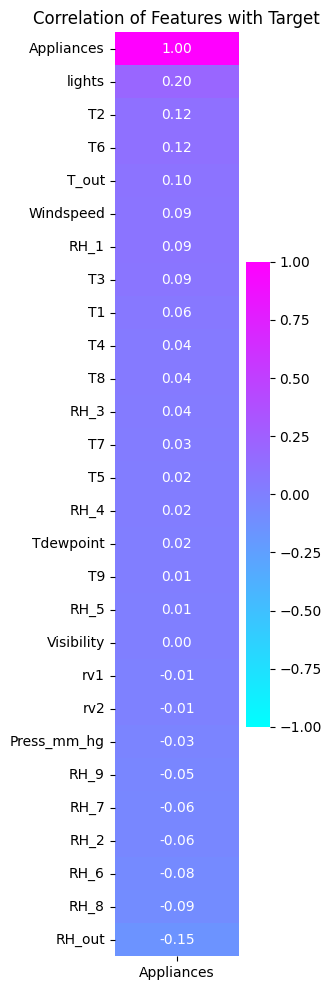

In [ ]:
target_corr=df.corr(numeric_only=True)[['Appliances']].sort_values(by='Appliances',ascending=False)

plt.figure(figsize=(2,12))
sns.heatmap(target_corr,
            annot=True,
            fmt=".2f",
            cmap='cool',
            vmin=-1,
            vmax=1,
            center=0)

plt.title('Correlation of Features with Target')
plt.show()

In [ ]:
df['Temperature Inside Building']=(df['T1']+df['T2']+df['T3']+df['T4']+df['T5']+df['T7']+df['T8']+df['T9'])/8

In [ ]:
df['Temperature Inside Building'].head()

,Temperature Inside Building
0,18.435000
1,18.439167
2,18.421667
3,18.396250
4,18.408750


In [ ]:
df['Temperature Outside Building']=(df['T6']+df['T_out'])/2

#combined Temperatures outside building(north side) and also from Chievres weather station
#as they share a very small difference

In [ ]:
df['Temperature Outside Building'].head()

,Temperature Outside Building
0,6.813333
1,6.656667
2,6.465000
3,6.341667
4,6.248333


In [ ]:
df['Humidity Inside Building']=(df['RH_1']+df['RH_2']+df['RH_3']+df['RH_4']+df['RH_7']+df['RH_8']+df['RH_9'])/7

In [ ]:
df['Humidity Inside Building'].head() #excluded bathroom as it had a different humididty percentage

,Humidity Inside Building
0,45.534286
1,45.454524
2,45.344762
3,45.237143
4,45.230476


In [ ]:
df['Humidity in Bathroom']=df['RH_5']

df['Humidity Outside Building(north)']=df['RH_6']

df['Humidity Outside(CWS)']=df['RH_out'] #CWS - Chievres Weather Station

In [ ]:
df.columns

Index(['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3',
       'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8',
       'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed',
       'Visibility', 'Tdewpoint', 'rv1', 'rv2', 'Temperature Inside Building',
       'Temperature Outside Building', 'Humidity Inside Building',
       'Humidity in Bathroom', 'Humidity Outside Building(north)',
       'Humidity Outside(CWS)'],
      dtype='object')

In [ ]:
df.drop(columns=['T1','T2','T3','T4','T5','T6','T7','T8','T9','T_out',
                 'RH_1','RH_2','RH_3','RH_4','RH_5','RH_6','RH_7','RH_8','RH_9','RH_out',
                 'Visibility','rv1','rv2'],
        axis=1,inplace=True)

As the features **Visibility, rv1, rv2** had near zero correlation, we dropped them too.

In [ ]:
df.isna().sum()

,0
date,0
Appliances,0
lights,0
Press_mm_hg,0
Windspeed,0
Tdewpoint,0
Temperature Inside Building,0
Temperature Outside Building,0
Humidity Inside Building,0
Humidity in Bathroom,0


In [ ]:
df.rename(columns={'lights': 'Lights'}, inplace=True)

In [ ]:
df['date']=pd.to_datetime(df['date'],format='mixed')

df['Year']=df['date'].dt.year
df['Month']=df['date'].dt.month
df['Day']=df['date'].dt.day

df['Hour']=df['date'].dt.hour

In [ ]:
df['Year'].value_counts()

,count
Year,
2016,19735


We will drop the Year feature too, because it contains only one unique value and does not contribute any useful information for prediction.

In [ ]:
df.drop(columns=['date','Year'],axis=1,inplace=True)

In [ ]:
df

,Appliances,Lights,Press_mm_hg,Windspeed,Tdewpoint,Temperature Inside Building,Temperature Outside Building,Humidity Inside Building,Humidity in Bathroom,Humidity Outside Building(north),Humidity Outside(CWS),Month,Day,Hour
0,60,30,733.5,7.000000,5.3,18.435000,6.813333,45.534286,55.200000,84.256667,92.000000,11,1,17
1,60,30,733.6,6.666667,5.2,18.439167,6.656667,45.454524,55.200000,84.063333,92.000000,11,1,17
2,50,30,733.7,6.333333,5.1,18.421667,6.465000,45.344762,55.090000,83.156667,92.000000,11,1,17
3,50,40,733.8,6.000000,5.0,18.396250,6.341667,45.237143,55.090000,83.423333,92.000000,11,1,17
4,60,40,733.9,5.666667,4.9,18.408750,6.248333,45.230476,55.090000,84.893333,92.000000,11,1,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19730,100,0,755.2,3.333333,13.3,24.869583,23.748333,45.243293,52.400000,1.000000,55.666667,5,27,17
19731,90,0,755.2,3.500000,13.3,24.846810,23.398333,45.198231,52.326667,1.000000,56.000000,5,27,17
19732,270,10,755.2,3.666667,13.3,24.818571,23.063333,45.376463,52.266667,1.000000,56.333333,5,27,17
19733,420,10,755.2,3.833333,13.2,24.758312,22.366667,45.391138,52.200000,1.000000,56.666667,5,27,17


In [ ]:
#Rounding off digits after decimal for better readability

df['Windspeed']=df['Windspeed'].round(2)
df['Temperature Inside Building']=df['Temperature Inside Building'].round(2)
df['Temperature Outside Building']=df['Temperature Outside Building'].round(2)
df['Humidity Inside Building']=df['Humidity Inside Building'].round(2)
df['Humidity in Bathroom']=df['Humidity in Bathroom'].round(2)
df['Humidity Outside Building(north)']=df['Humidity Outside Building(north)'].round(2)
df['Humidity Outside(CWS)']=df['Humidity Outside(CWS)'].round(2)

In [ ]:
df.head()

,Appliances,Lights,Press_mm_hg,Windspeed,Tdewpoint,Temperature Inside Building,Temperature Outside Building,Humidity Inside Building,Humidity in Bathroom,Humidity Outside Building(north),Humidity Outside(CWS),Month,Day,Hour
0,60,30,733.5,7.00,5.3,18.43,6.81,45.53,55.20,84.26,92.0,11,1,17
1,60,30,733.6,6.67,5.2,18.44,6.66,45.45,55.20,84.06,92.0,11,1,17
2,50,30,733.7,6.33,5.1,18.42,6.46,45.34,55.09,83.16,92.0,11,1,17
3,50,40,733.8,6.00,5.0,18.40,6.34,45.24,55.09,83.42,92.0,11,1,17
4,60,40,733.9,5.67,4.9,18.41,6.25,45.23,55.09,84.89,92.0,11,1,17


In [ ]:
df.shape

(19735, 14)

This is the final count of Rows(19735) and Columns(12).

In [ ]:
'''df.to_csv("clean_energy.csv",index=False)
from google.colab import files
files.download("clean_energy.csv")'''

'df.to_csv("clean_energy.csv",index=False)\nfrom google.colab import files\nfiles.download("clean_energy.csv")'

This will get us a cleaned and feature engineered Dataset.

In [ ]:
df['Appliances'].value_counts()

,count
Appliances,
50,4368
60,3282
40,2019
70,1560
80,1205
...,...
860,1
880,1
900,1


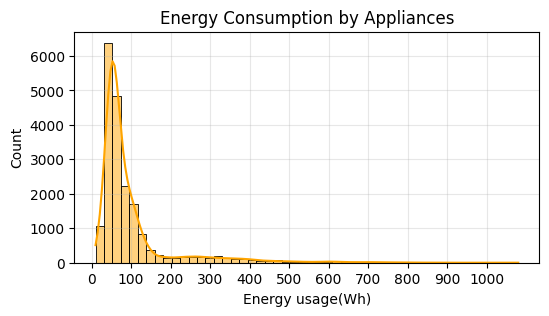

In [ ]:
plt.figure(figsize=(6,3))
sns.histplot(df['Appliances'],bins=50,kde=True,color="orange")
plt.xticks(range(0,1100,100))
plt.xlabel('Energy usage(Wh)')
plt.title('Energy Consumption by Appliances')
plt.grid(alpha=0.3)
plt.show()

Energy consumption is heavily right-skewed, with most values concentrated at lower levels and a few extreme high-usage outliers.

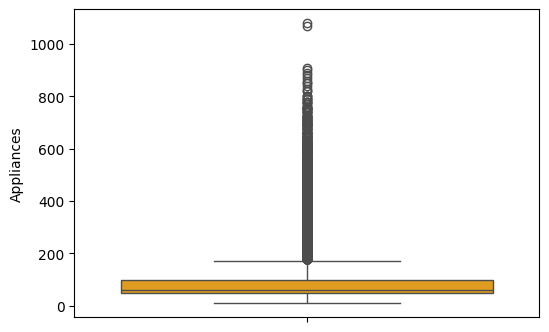

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['Appliances'],color="orange")
plt.show()

*   As there are numerous Outliers, but those high values represent real world high energy consumption.
*    So removing them would reduce the model's ability to generalize.

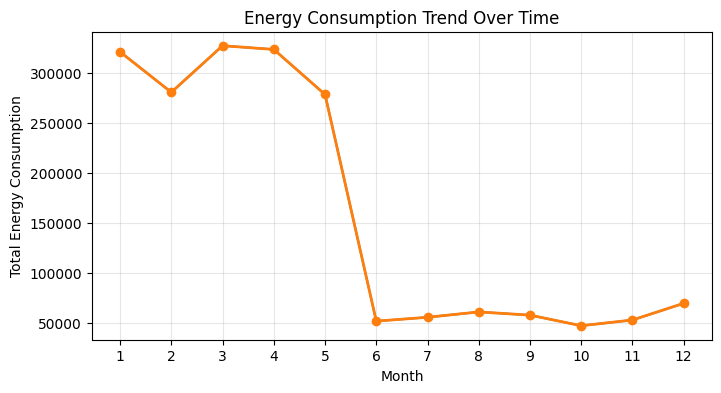

In [ ]:
trend=df.groupby('Month')['Appliances'].sum()

plt.figure(figsize=(8,4))

trend.plot()
plt.plot(trend.index,trend.values,marker='o',linewidth=2)
plt.xticks(range(1,13))

plt.title('Energy Consumption Trend Over Time')
plt.xlabel('Month')
plt.ylabel('Total Energy Consumption')

plt.grid(alpha=0.3)
plt.show()

Energy consumption remains high in the initial months, drops sharply around mid-year, and then stabilizes at lower levels with slight fluctuations.

In [ ]:
df['Lights'].value_counts()

,count
Lights,
0,15252
10,2212
20,1624
30,559
40,77
50,9
70,1
60,1


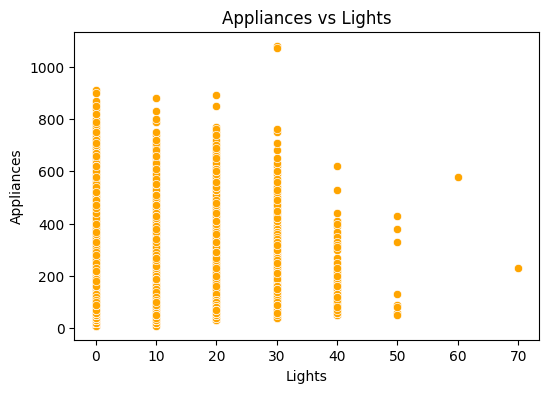

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Lights'],y=df['Appliances'],color="orange")
plt.title('Appliances vs Lights')
plt.show()

The above graph shows no strong linear relationship with lights usage, though higher appliance usage appears more frequent at lower light levels.

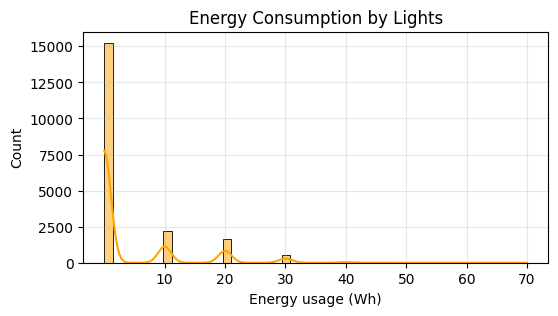

In [ ]:
plt.figure(figsize=(6,3))
sns.histplot(df['Lights'],bins=50,kde=True,color="orange")
plt.xticks(range(10,80,10))
plt.xlabel('Energy usage (Wh)')
plt.title('Energy Consumption by Lights')
plt.grid(alpha=0.3)
plt.show()

Lighting energy usage is highly right-skewed, with most observations at very low values and a few higher consumption spikes.

In [ ]:
df['Humidity in Bathroom'].value_counts()

,count
Humidity in Bathroom,
49.00,90
46.70,83
45.00,83
51.00,81
47.50,80
...,...
38.43,1
76.02,1
79.53,1


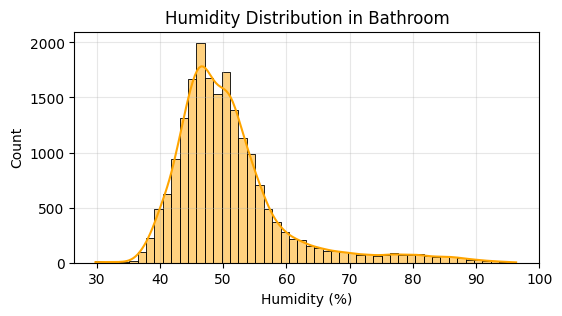

In [ ]:
plt.figure(figsize=(6,3))
sns.histplot(df['Humidity in Bathroom'],bins=50,kde=True,color="orange")
plt.xticks(range(30,110,10))
plt.xlabel('Humidity (%)')
plt.title('Humidity Distribution in Bathroom')
plt.grid(alpha=0.3)
plt.show()

Bathroom humidity is slightly right-skewed, with most values clustered around moderate levels and a gradual tail toward higher humidity.

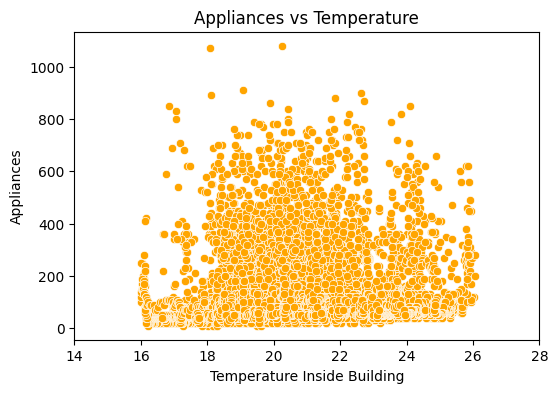

In [ ]:
plt.figure(figsize=(6,4))

sns.scatterplot(x=df['Temperature Inside Building'],y=df['Appliances'],color="orange")

plt.xticks(range(14,30,2))
plt.title('Appliances vs Temperature')
plt.show()

Energy consumption shows a mild positive trend with temperature, but the wide spread indicates a weak and inconsistent relationship.

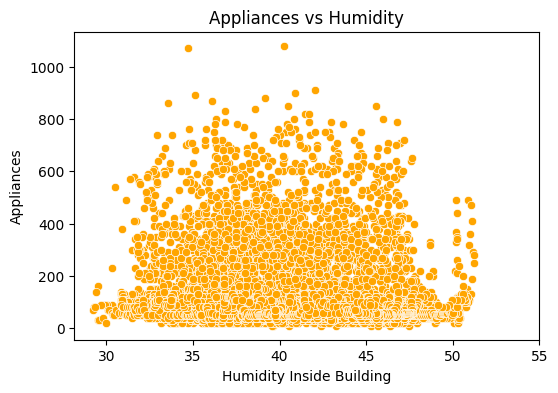

In [ ]:
plt.figure(figsize=(6,4))

sns.scatterplot(x=df['Humidity Inside Building'],y=df['Appliances'],color="orange")

plt.xticks(range(30,60,5))
plt.title('Appliances vs Humidity')
plt.show()

It shows a weak and scattered relationship with indoor humidity, indicating humidity has limited direct impact on appliance usage.

In [ ]:
#Log transformation was applied to reduce skewness and stabilize variance in the target variable.

df['Appliances']=np.log1p(df['Appliances'])
df['Lights']=np.log1p(df['Lights'])

*   As these features were heavily skewed, we applied ***log transformation***.

*   Also, we observed the skewness in the "Month" feature, but avoided to apply transformation because it is a categorical time feature and not a continuous variable.

# Splitting Data into X & Y

In [ ]:
x=df.drop('Appliances',axis=1)
y=(df['Appliances'])

# Model Selection

*   Tree-based models like Random Forest and XGBoost were preferred due to their robustness to skewness and outliers, while Linear Regression was used as a baseline model.
*   Other models such as SVM and KNN were avoided due to their sensitivity to scaling and computational inefficiency on large datasets.

In [ ]:
# Splitting dataset into training and testing sets for model evaluation.

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=123)

# Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

lr=LinearRegression()

lr.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pred=lr.predict(x_test)

In [ ]:
mean_absolute_error(y_test,y_pred)

0.4037741720473872

In [ ]:
root_mean_squared_error(y_test,y_pred)

0.5822864683595489

In [ ]:
r2_score(y_test,y_pred)*100

18.720136450464775

# Random Forest

In [ ]:
# Random Forest is used as it handles non-linear relationships,
# skewness, and outliers effectively without requiring scaling.

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf=RandomForestRegressor()

params={
    'n_estimators':[100,150], # Number of trees in the forest(more trees = better performance but slower)
    'max_depth':[10,15],      # Maximum depth of each tree (controls overfitting)
    'min_samples_leaf':[1,2], # Minimum samples required at a leaf node (prevents overfitting)
    'bootstrap':[True,False]  # Whether to use bootstrap sampling (random sampling with replacement)
}

gsc_rf=GridSearchCV(
    estimator=rf,        # Base model(Random Forest) to tune
    param_grid=params,   # Hyperparameter combinations to try
    cv=2,                # Number of cross-validation folds (2-fold CV)
    scoring='r2',        # Evaluation metric (R-squared for regression)
    n_jobs=-1            # Use all CPU cores for faster computation
)

gsc_rf.fit(x_train,y_train)

GridSearchCV(cv=2, estimator=RandomForestRegressor(), n_jobs=-1,
             param_grid={'bootstrap': [True, False], 'max_depth': [10, 15],
                         'min_samples_leaf': [1, 2],
                         'n_estimators': [100, 150]},
             scoring='r2')

In [ ]:
gsc_rf.best_params_

{'bootstrap': True,
 'max_depth': 15,
 'min_samples_leaf': 1,
 'n_estimators': 150}

In [ ]:
y_pred_rf=gsc_rf.best_estimator_.predict(x_test)

In [ ]:
mean_absolute_error(y_test,y_pred_rf)

0.25891162428036574

In [ ]:
root_mean_squared_error(y_test,y_pred_rf)

0.39032691262223107

In [ ]:
r2_score(y_test,y_pred_rf)*100

63.47698990871079

# XGBoost

In [ ]:
# XGBoost is used for its high performance and ability to capture
# complex patterns through boosting.

from xgboost.sklearn import XGBRegressor

xgb=XGBRegressor()

param={
    'learning_rate':[0.03,0.05,0.1], # Step size for updating weights(lower = slower but more accurate learning)
    'max_depth': [4,5,6],            # Maximum depth of each tree(controls model complexity)
    'min_child_weight':[1,3],        # Minimum sum of instance weight needed in a child(prevents overfitting)
    'n_estimators':[200,300]         # Number of boosting rounds (number of trees)
}

gsc_xg=GridSearchCV(
    estimator=xgb,       # Base model(XGBoost Regressor) to tune
    param_grid=param,    # Hyperparameter combinations to search
    scoring='r2'         # Evaluation metric(R-squared for regression)
)

gsc_xg.fit(x_train,y_train)

GridSearchCV(estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,
                                    lear...
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.03, 0.05, 0.1],
                         'max_depth': [4, 5, 6], 'min_child_weight': [1, 3],
                         'n_estimators': [200, 300]},
             scoring='r2')

In [ ]:
gsc_xg.best_params_

{'learning_rate': 0.1,
 'max_depth': 6,
 'min_child_weight': 3,
 'n_estimators': 300}

In [ ]:
y_pred_xg=gsc_xg.best_estimator_.predict(x_test)

In [ ]:
mean_absolute_error(y_test,y_pred_xg)

0.25904827011345544

In [ ]:
root_mean_squared_error(y_test,y_pred_xg)

0.38173819078527

In [ ]:
r2_score(y_test,y_pred_xg)*100

65.06660519721783

# Feature Importance

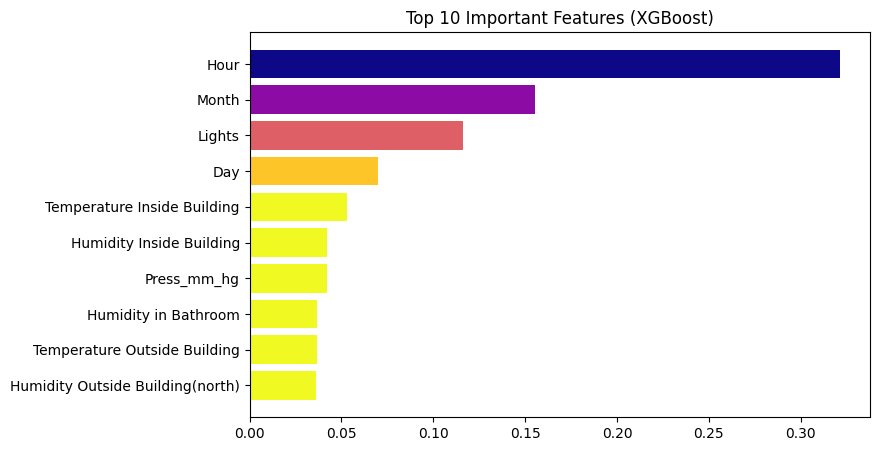

In [ ]:
xg_importance=gsc_xg.best_estimator_.feature_importances_

xg_df=pd.DataFrame({
    'Feature': x.columns,
    'Importance': xg_importance
}).sort_values(by='Importance',ascending=False)

top_n=10
xg_df_top=xg_df.head(top_n)

colors=plt.cm.plasma(np.linspace(0,3.5,len(xg_df)))

plt.figure(figsize=(8,5))
plt.barh(xg_df_top['Feature'],xg_df_top['Importance'],color=colors)
plt.gca().invert_yaxis()
plt.title('Top 10 Important Features (XGBoost)')
plt.show()

# SHAP

In [ ]:
# Applying SHAP to interpret model predictions and understand feature contributions.

!pip install shap --quiet
import shap

100%|===================| 3938/3947 [01:20<00:00]       

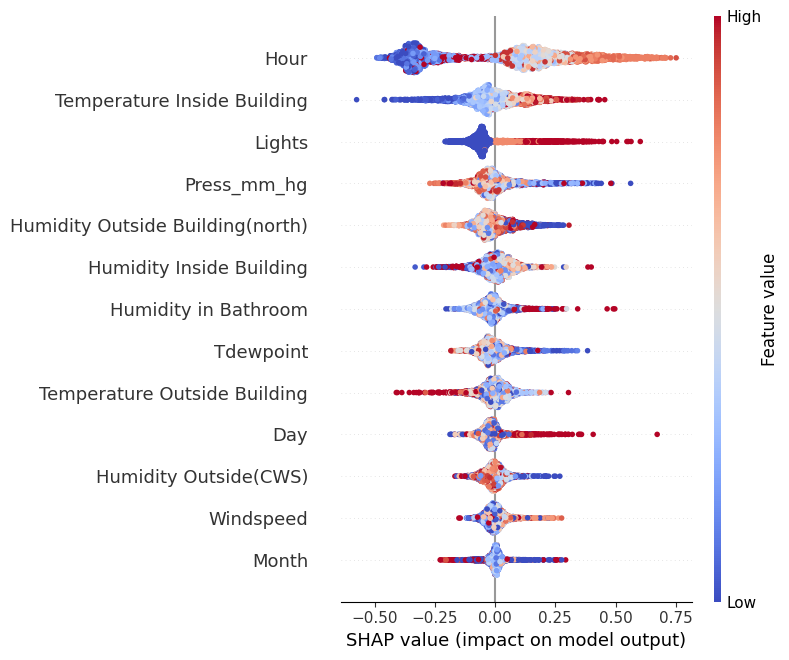

In [ ]:
explainer=shap.Explainer(gsc_xg.best_estimator_,x_train)
shap_values=explainer(x_test)
shap.summary_plot(shap_values,x_test,cmap='coolwarm')

In [ ]:
# SHAP analysis shows that time (Hour), temperature, and lighting
# are key drivers of energy consumption.

# Conclusion

*   Our project analyzed and predicted appliance energy consumption using machine learning techniques. The dataset showed skewness and outliers, which were addressed through preprocessing and feature engineering.

*   Tree-based models like Random Forest and XGBoost performed better due to their ability to handle non-linear and skewed data, with XGBoost achieving an R² score of 65.06% .

*   SHAP analysis improved model interpretability by identifying key factors such as hour, indoor temperature, and lighting as major contributors to energy usage.

*   Overall, the project highlights the importance of proper preprocessing and model selection in handling complex, real-world energy data, with scope for further improvement through advanced tuning and feature enhancement.